# Hands-On Week 11 — Statistical Modeling & Prediction: Linear Regression (Python)

**Mata kuliah:** Pengantar Data Sains  
**Topik utama:** Linear regression, assumptions, interpretation, dan prediction  
**Konteks:** Praktik pemodelan statistik dan prediksi menggunakan Python

---

## Capaian Pembelajaran

Setelah menyelesaikan hands-on ini, mahasiswa diharapkan mampu:

1. menjelaskan perbedaan **model statistik**, **estimasi**, **inferensi**, dan **prediksi**;
2. memahami bentuk umum **regresi linear sederhana** dan **regresi linear berganda**;
3. menghitung dan menginterpretasikan koefisien regresi, residual, fitted values, $R^2$, adjusted $R^2$, MAE, RMSE, dan test error;
4. membedakan **confidence interval** untuk rerata respons dan **prediction interval** untuk observasi baru;
5. memeriksa asumsi utama regresi linear melalui diagnostik residual;
6. menginterpretasikan koefisien regresi secara kontekstual, termasuk interpretasi *ceteris paribus* pada regresi berganda;
7. menggunakan regresi linear untuk tujuan **explanation**, **estimation**, dan **prediction** secara hati-hati.

---

## Struktur Notebook

Notebook ini mengikuti pola hands-on sebelumnya:

- konsep inti dan rumus;
- simulasi dataset sintetis;
- eksplorasi data;
- regresi linear sederhana;
- regresi linear berganda;
- diagnostik asumsi;
- prediksi dan evaluasi pada data uji;
- interpretasi, latihan, tugas, dan rubrik penilaian.

Dataset dibuat secara sintetis agar notebook dapat dijalankan tanpa koneksi internet.


# Bagian A — Persiapan Lingkungan Kerja

Pada bagian awal, kita memanggil pustaka yang diperlukan. Kita menggunakan `np.random.seed()` agar simulasi dapat direplikasi. Seluruh data yang digunakan dalam notebook ini dibuat secara sintetis dengan konteks pendidikan.


In [1]:
import numpy as np                 # Komputasi numerik dan simulasi data acak
import pandas as pd                # Pengolahan data berbentuk tabel
import matplotlib.pyplot as plt    # Visualisasi dasar

from scipy import stats            # Distribusi probabilitas dan uji statistik

import statsmodels.api as sm       # Model statistik, OLS, ringkasan regresi
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson, jarque_bera

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(123)
pd.set_option('display.max_columns', 100)
pd.set_option('display.precision', 4)


## Catatan Pembelajaran

Regresi linear dapat digunakan untuk beberapa tujuan yang berbeda:

1. **Deskripsi hubungan**: menjelaskan pola asosiasi antara variabel respons dan prediktor.
2. **Estimasi efek/asosiasi bersyarat**: mengestimasi perubahan rerata respons ketika prediktor berubah.
3. **Inferensi**: menilai ketidakpastian koefisien melalui standard error, confidence interval, dan uji hipotesis.
4. **Prediksi**: memprediksi nilai respons pada observasi baru.

Satu model dapat terlihat baik untuk prediksi tetapi belum tentu baik untuk inferensi klasik apabila asumsi residual sangat bermasalah. Sebaliknya, model yang valid untuk inferensi belum tentu memiliki akurasi prediktif terbaik pada data baru.


# Bagian B — Konsep Dasar Regresi Linear

## B.1 Model Regresi Linear Sederhana

Regresi linear sederhana memodelkan hubungan antara satu variabel respons $Y$ dan satu prediktor $X$:

$$
Y_i = \beta_0 + \beta_1 X_i + \varepsilon_i, \qquad i=1,2,\ldots,n.
$$

Makna komponen model:

- $Y_i$: nilai respons pada observasi ke-$i$;
- $X_i$: nilai prediktor pada observasi ke-$i$;
- $\beta_0$: intercept, yaitu rerata respons ketika $X=0$;
- $\beta_1$: slope, yaitu perubahan rerata respons untuk setiap kenaikan satu unit $X$;
- $\varepsilon_i$: error acak yang mencakup faktor lain di luar model.

Rerata bersyarat respons ditulis sebagai:

$$
E(Y_i \mid X_i=x_i)=\beta_0+\beta_1x_i.
$$


## B.2 Estimasi Least Squares

Koefisien regresi diestimasi menggunakan prinsip **ordinary least squares** (OLS), yaitu memilih $\hat\beta_0$ dan $\hat\beta_1$ yang meminimumkan jumlah kuadrat residual:

$$
SSE = \sum_{i=1}^{n} e_i^2
= \sum_{i=1}^{n}(y_i-\hat{y}_i)^2.
$$

Dengan:

$$
\hat{y}_i=\hat\beta_0+\hat\beta_1x_i,
\qquad
 e_i=y_i-\hat{y}_i.
$$

Untuk regresi linear sederhana:

$$
\hat\beta_1 = \frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}
{\sum_{i=1}^{n}(x_i-\bar{x})^2},
\qquad
\hat\beta_0 = \bar{y}-\hat\beta_1\bar{x}.
$$


In [2]:
# Contoh sederhana menghitung koefisien regresi sederhana secara manual
x_demo = np.array([1, 2, 3, 4, 5], dtype=float)
y_demo = np.array([2.2, 2.8, 3.6, 4.5, 5.1], dtype=float)

x_bar = x_demo.mean()
y_bar = y_demo.mean()

beta1_hat = np.sum((x_demo - x_bar) * (y_demo - y_bar)) / np.sum((x_demo - x_bar)**2)
beta0_hat = y_bar - beta1_hat * x_bar

y_hat_demo = beta0_hat + beta1_hat * x_demo
resid_demo = y_demo - y_hat_demo

print(f"beta0_hat = {beta0_hat:.4f}")
print(f"beta1_hat = {beta1_hat:.4f}")
print("Residual:", np.round(resid_demo, 4))
print("SSE =", np.sum(resid_demo**2).round(4))


beta0_hat = 1.3900
beta1_hat = 0.7500
Residual: [ 0.06 -0.09 -0.04  0.11 -0.04]
SSE = 0.027


## B.3 Model Regresi Linear Berganda

Regresi linear berganda menggunakan lebih dari satu prediktor:

$$
Y_i = \beta_0 + \beta_1X_{i1}+\beta_2X_{i2}+\cdots+\beta_pX_{ip}+\varepsilon_i.
$$

Dalam bentuk matriks:

$$
\mathbf{y}=\mathbf{X}\boldsymbol{\beta}+\boldsymbol{\varepsilon}.
$$

Estimator OLS dalam bentuk matriks adalah:

$$
\hat{\boldsymbol{\beta}}
=
(\mathbf{X}'\mathbf{X})^{-1}\mathbf{X}'\mathbf{y},
$$

jika $\mathbf{X}'\mathbf{X}$ invertibel.

Interpretasi koefisien pada regresi berganda bersifat **ceteris paribus**:

> $\hat\beta_j$ mengestimasi perubahan rerata $Y$ untuk kenaikan satu unit $X_j$, dengan prediktor lain dianggap tetap.


## Checkpoint 1

Jawab secara singkat:

1. Apa perbedaan respons dan prediktor?
2. Apa makna residual $e_i$?
3. Mengapa metode OLS meminimumkan jumlah kuadrat residual?
4. Apa perbedaan interpretasi slope pada regresi sederhana dan regresi berganda?


In [ ]:
# Ruang jawaban Checkpoint 1
# Tulis jawaban Anda sebagai komentar di bawah ini.


# Bagian C — Membuat Dataset Sintetis

Kita membuat dataset sintetis tentang performa akademik mahasiswa. Unit analisis adalah **mahasiswa**.

Variabel yang digunakan:

| Variabel | Jenis | Penjelasan |
|---|---|---|
| `study_hours` | numerik | rata-rata jam belajar per hari |
| `attendance_rate` | numerik | persentase kehadiran kuliah |
| `prior_score` | numerik | skor awal atau nilai prasyarat |
| `sleep_hours` | numerik | rata-rata jam tidur per hari |
| `tutoring` | kategorik | apakah mahasiswa mengikuti bimbingan tambahan |
| `final_score` | numerik | nilai akhir mata kuliah |

Hubungan data dirancang agar `final_score` meningkat ketika `study_hours`, `attendance_rate`, dan `prior_score` meningkat. Variabel `sleep_hours` dibuat memiliki hubungan melengkung ringan agar mahasiswa melihat bahwa tidak semua hubungan selalu linear sempurna.


In [3]:
# Membuat dataset sintetis pendidikan
n = 220

study_hours = np.random.gamma(shape=2.2, scale=1.3, size=n)
study_hours = np.clip(study_hours, 0.2, 8.0)

prior_score = np.random.normal(loc=68, scale=10, size=n)
prior_score = np.clip(prior_score, 35, 95)

attendance_rate = 58 + 4.2 * study_hours + np.random.normal(0, 8, size=n)
attendance_rate = np.clip(attendance_rate, 35, 100)

sleep_hours = np.random.normal(loc=6.7, scale=1.0, size=n)
sleep_hours = np.clip(sleep_hours, 3.5, 9.5)

tutoring_prob = 1 / (1 + np.exp(-(study_hours - 2.8)))
tutoring = np.where(np.random.binomial(1, tutoring_prob, size=n) == 1, 'Ya', 'Tidak')

noise = np.random.normal(0, 5.0, size=n)

# Model pembangkit data: hubungan utama linear + sedikit efek melengkung dari jam tidur
final_score = (
    14
    + 3.4 * study_hours
    + 0.28 * attendance_rate
    + 0.42 * prior_score
    + 2.7 * (tutoring == 'Ya')
    - 1.1 * (sleep_hours - 7.0)**2
    + noise
)
final_score = np.clip(final_score, 0, 100)

df = pd.DataFrame({
    'study_hours': study_hours,
    'attendance_rate': attendance_rate,
    'prior_score': prior_score,
    'sleep_hours': sleep_hours,
    'tutoring': tutoring,
    'final_score': final_score
})

# Menambahkan beberapa nilai hilang kecil untuk latihan pembersihan data
missing_idx = np.random.choice(df.index, size=5, replace=False)
df.loc[missing_idx[:2], 'study_hours'] = np.nan
df.loc[missing_idx[2:], 'prior_score'] = np.nan

# Menambahkan satu observasi ekstrem agar mahasiswa melihat pengaruh outlier/influence
outlier_row = pd.DataFrame({
    'study_hours': [7.8],
    'attendance_rate': [96.0],
    'prior_score': [92.0],
    'sleep_hours': [4.0],
    'tutoring': ['Ya'],
    'final_score': [58.0]
})
df = pd.concat([df, outlier_row], ignore_index=True)

print("Dataset berhasil dibuat.")
df.head()


Dataset berhasil dibuat.


,study_hours,attendance_rate,prior_score,sleep_hours,tutoring,final_score
0,0.9641,63.5206,70.4403,5.4733,Tidak,57.6167
1,4.6641,71.9525,66.4415,7.2674,Tidak,83.3741
2,1.5372,58.7715,75.7369,6.4098,Tidak,71.4893
3,6.7004,88.3014,59.9184,7.1610,Ya,83.5440
4,0.2000,61.1591,74.8840,5.8863,Tidak,64.4765


# Bagian D — Pemeriksaan Awal Dataset

Sebelum membuat model, kita perlu memahami struktur data. Pemeriksaan awal minimal meliputi:

- ukuran data (`shape`);
- contoh baris (`head()`);
- tipe data (`info()`);
- statistik deskriptif (`describe()`);
- jumlah nilai hilang;
- duplikasi;
- ringkasan variabel target.


In [4]:
print("Shape:", df.shape)
df.head()


Shape: (221, 6)


,study_hours,attendance_rate,prior_score,sleep_hours,tutoring,final_score
0,0.9641,63.5206,70.4403,5.4733,Tidak,57.6167
1,4.6641,71.9525,66.4415,7.2674,Tidak,83.3741
2,1.5372,58.7715,75.7369,6.4098,Tidak,71.4893
3,6.7004,88.3014,59.9184,7.1610,Ya,83.5440
4,0.2000,61.1591,74.8840,5.8863,Tidak,64.4765


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   study_hours      219 non-null    float64
 1   attendance_rate  221 non-null    float64
 2   prior_score      218 non-null    float64
 3   sleep_hours      221 non-null    float64
 4   tutoring         221 non-null    object 
 5   final_score      221 non-null    float64
dtypes: float64(5), object(1)
memory usage: 10.5+ KB


In [6]:
df.describe(include='all')


,study_hours,attendance_rate,prior_score,sleep_hours,tutoring,final_score
count,219.0000,221.0000,218.0000,221.0000,221,221.0000
unique,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,NaN,NaN,Tidak,NaN
freq,NaN,NaN,NaN,NaN,115,NaN
mean,2.7967,68.6803,68.2519,6.6761,NaN,71.6855
std,1.8151,11.4202,10.1643,0.8807,NaN,11.8038
min,0.2000,37.5043,38.9995,4.0000,NaN,42.1989
25%,1.4279,61.1591,61.2710,6.0804,NaN,63.6363
50%,2.2762,67.0902,68.2627,6.7063,NaN,70.5341
75%,3.7759,76.1447,74.8042,7.2674,NaN,78.4549


In [7]:
# Pemeriksaan kualitas data sederhana
quality_summary = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percent': 100 * df.isna().mean(),
    'dtype': df.dtypes.astype(str)
})
quality_summary


,missing_count,missing_percent,dtype
study_hours,2,0.9050,float64
attendance_rate,0,0.0000,float64
prior_score,3,1.3575,float64
sleep_hours,0,0.0000,float64
tutoring,0,0.0000,object
final_score,0,0.0000,float64


In [8]:
print("Jumlah baris duplikat:", df.duplicated().sum())
print("Ringkasan final_score:")
print(df['final_score'].describe())


Jumlah baris duplikat: 0
Ringkasan final_score:
count    221.0000
mean      71.6855
std       11.8038
min       42.1989
25%       63.6363
50%       70.5341
75%       78.4549
max      100.0000
Name: final_score, dtype: float64


## D.1 Penanganan Nilai Hilang

Untuk hands-on ini, nilai hilang ditangani dengan cara sederhana:

- variabel numerik diisi dengan median;
- variabel kategorik diisi dengan modus.

Catatan penting: pada riset nyata, strategi imputasi harus disesuaikan dengan mekanisme nilai hilang, tujuan analisis, dan konteks substansial data.


In [9]:
df_clean = df.copy()

num_cols = df_clean.select_dtypes(include='number').columns
cat_cols = df_clean.select_dtypes(exclude='number').columns

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Jumlah missing setelah imputasi:")
print(df_clean.isna().sum())


Jumlah missing setelah imputasi:
study_hours        0
attendance_rate    0
prior_score        0
sleep_hours        0
tutoring           0
final_score        0
dtype: int64


# Bagian E — Eksplorasi Hubungan Antarvariabel

Regresi linear harus dimulai dari eksplorasi data. Kita perlu memeriksa apakah hubungan antara respons dan prediktor tampak cukup linear, apakah ada outlier ekstrem, dan apakah pola data masuk akal secara substantif.


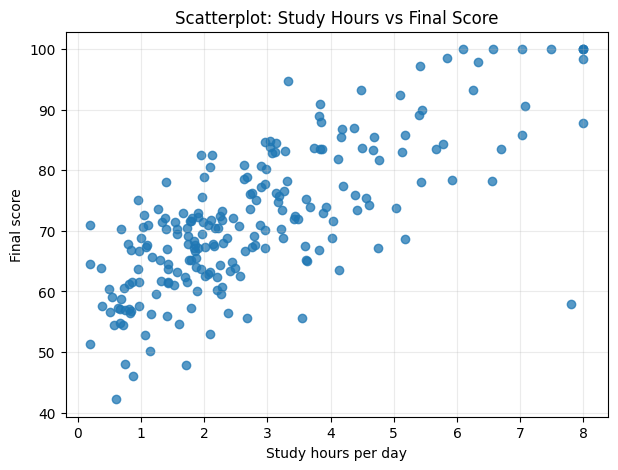

In [10]:
# Scatterplot final_score terhadap study_hours
plt.figure(figsize=(7, 5))
plt.scatter(df_clean['study_hours'], df_clean['final_score'], alpha=0.75)
plt.xlabel('Study hours per day')
plt.ylabel('Final score')
plt.title('Scatterplot: Study Hours vs Final Score')
plt.grid(alpha=0.25)
plt.show()


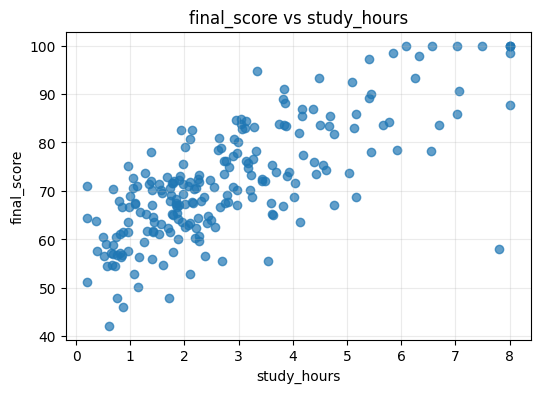

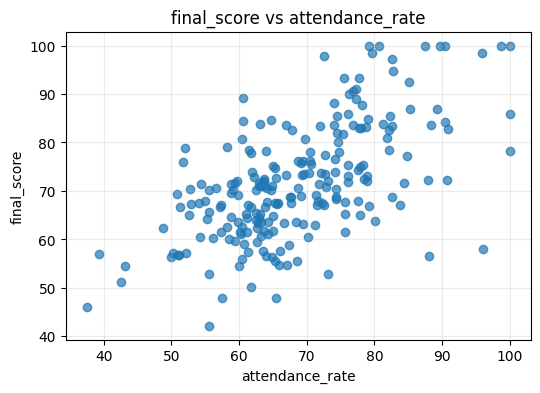

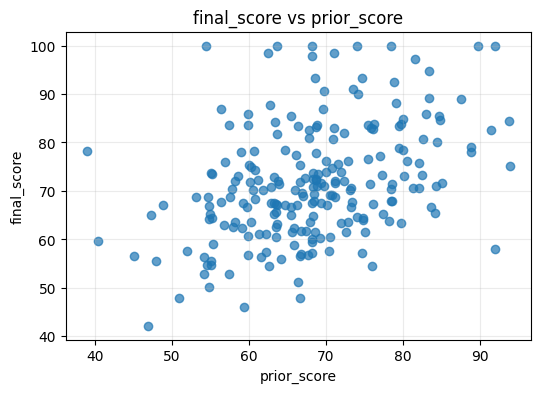

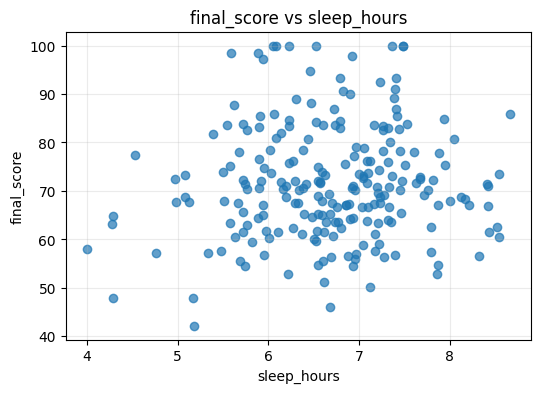

In [11]:
# Scatterplot respons terhadap beberapa prediktor numerik
predictors = ['study_hours', 'attendance_rate', 'prior_score', 'sleep_hours']

for col in predictors:
    plt.figure(figsize=(6, 4))
    plt.scatter(df_clean[col], df_clean['final_score'], alpha=0.70)
    plt.xlabel(col)
    plt.ylabel('final_score')
    plt.title(f'final_score vs {col}')
    plt.grid(alpha=0.25)
    plt.show()


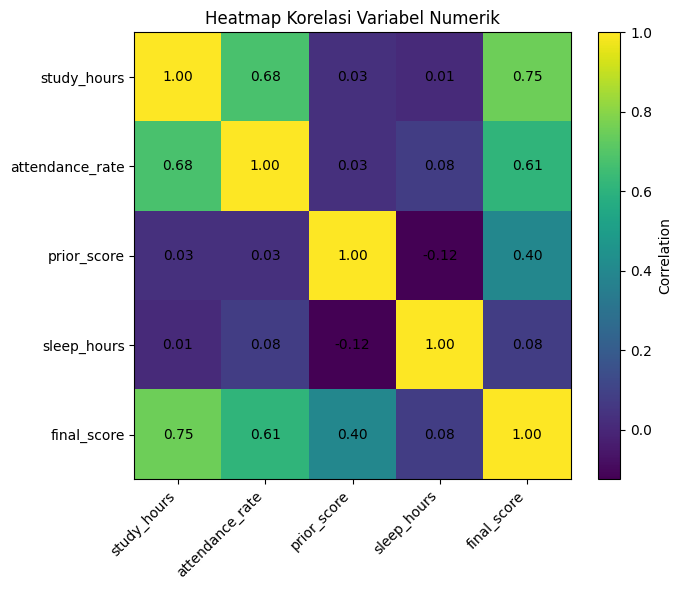

In [12]:
# Korelasi variabel numerik
corr = df_clean.select_dtypes(include='number').corr()

plt.figure(figsize=(7, 6))
plt.imshow(corr, aspect='auto')
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.index)), corr.index)
plt.title('Heatmap Korelasi Variabel Numerik')

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center')

plt.tight_layout()
plt.show()


## Checkpoint 2

Jawab berdasarkan visualisasi:

1. Prediktor mana yang tampak memiliki hubungan paling kuat dengan `final_score`?
2. Apakah hubungan `study_hours` dan `final_score` tampak cukup linear?
3. Apakah terlihat observasi yang mencurigakan atau berpotensi outlier?
4. Mengapa korelasi tinggi antarprediktor perlu diperhatikan dalam regresi berganda?


In [ ]:
# Ruang jawaban Checkpoint 2
# Tulis jawaban Anda sebagai komentar di bawah ini.


# Bagian F — Regresi Linear Sederhana

Kita mulai dengan model sederhana:

$$
\texttt{final\_score}_i = \beta_0 + \beta_1\texttt{study\_hours}_i + \varepsilon_i.
$$

Model ini menjawab pertanyaan:

> Bagaimana hubungan rata-rata nilai akhir dengan rata-rata jam belajar per hari?


In [14]:
model_simple = smf.ols('final_score ~ study_hours', data=df_clean).fit()
print(model_simple.summary())


                            OLS Regression Results                            
Dep. Variable:            final_score   R-squared:                       0.564
Model:                            OLS   Adj. R-squared:                  0.562
Method:                 Least Squares   F-statistic:                     283.1
Date:                Sat, 09 May 2026   Prob (F-statistic):           2.48e-41
Time:                        12:23:55   Log-Likelihood:                -766.92
No. Observations:                 221   AIC:                             1538.
Df Residuals:                     219   BIC:                             1545.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      57.9947      0.969     59.872      

## F.1 Interpretasi Koefisien Regresi Sederhana

Misalkan hasil estimasi model sederhana adalah:

$$
\widehat{Y}=\hat\beta_0+\hat\beta_1X.
$$

Interpretasi:

- $\hat\beta_0$: prediksi nilai akhir ketika `study_hours = 0`. Interpretasi ini harus hati-hati jika $X=0$ berada di luar rentang data atau tidak masuk akal secara substantif.
- $\hat\beta_1$: estimasi perubahan rata-rata `final_score` untuk setiap tambahan 1 jam belajar per hari.

Jika $\hat\beta_1=3.5$, maka mahasiswa dengan jam belajar 1 jam lebih tinggi diperkirakan memiliki nilai akhir rata-rata 3.5 poin lebih tinggi, dalam model sederhana ini.


In [15]:
# Parameter utama model sederhana
params_simple = model_simple.params
conf_simple = model_simple.conf_int()

summary_simple = pd.DataFrame({
    'coef': params_simple,
    'ci_lower': conf_simple[0],
    'ci_upper': conf_simple[1],
    'p_value': model_simple.pvalues
})
summary_simple


,coef,ci_lower,ci_upper,p_value
Intercept,57.9947,56.0856,59.9038,9.7940e-138
study_hours,4.9037,4.3293,5.4780,2.4807e-41


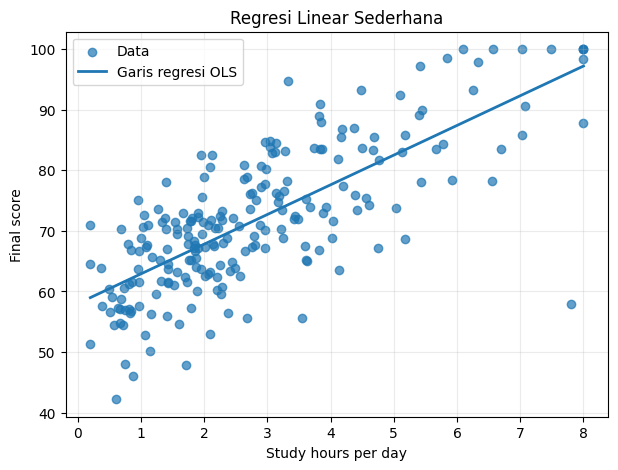

In [16]:
# Visualisasi garis regresi sederhana
x_grid = np.linspace(df_clean['study_hours'].min(), df_clean['study_hours'].max(), 100)
pred_grid = model_simple.predict(pd.DataFrame({'study_hours': x_grid}))

plt.figure(figsize=(7, 5))
plt.scatter(df_clean['study_hours'], df_clean['final_score'], alpha=0.70, label='Data')
plt.plot(x_grid, pred_grid, linewidth=2, label='Garis regresi OLS')
plt.xlabel('Study hours per day')
plt.ylabel('Final score')
plt.title('Regresi Linear Sederhana')
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## F.2 Fitted Values, Residuals, dan Error

Untuk setiap observasi:

$$
\hat{y}_i = \hat\beta_0+\hat\beta_1x_i,
\qquad
 e_i = y_i-\hat{y}_i.
$$

Residual positif berarti nilai aktual lebih tinggi daripada nilai prediksi. Residual negatif berarti nilai aktual lebih rendah daripada nilai prediksi.


In [17]:
df_simple_result = df_clean.copy()
df_simple_result['fitted_simple'] = model_simple.fittedvalues
df_simple_result['resid_simple'] = model_simple.resid

df_simple_result[['study_hours', 'final_score', 'fitted_simple', 'resid_simple']].head(10)


,study_hours,final_score,fitted_simple,resid_simple
0,0.9641,57.6167,62.7222,-5.1055
1,4.6641,83.3741,80.8658,2.5083
2,1.5372,71.4893,65.5328,5.9565
3,6.7004,83.5440,90.8510,-7.3071
4,0.2000,64.4765,58.9754,5.5010
5,1.7418,67.9085,66.5359,1.3727
6,1.4096,67.0169,64.9067,2.1102
7,2.2623,59.6190,69.0883,-9.4693
8,1.7204,47.9016,66.4311,-18.5295
9,1.7341,70.5180,66.4980,4.0200


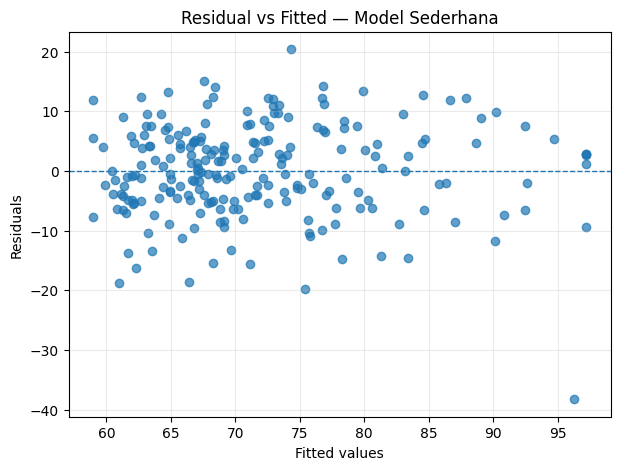

In [18]:
plt.figure(figsize=(7, 5))
plt.scatter(df_simple_result['fitted_simple'], df_simple_result['resid_simple'], alpha=0.70)
plt.axhline(0, linestyle='--', linewidth=1)
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residual vs Fitted — Model Sederhana')
plt.grid(alpha=0.25)
plt.show()


# Bagian G — Ukuran Kecocokan Model

Beberapa ukuran penting pada regresi linear:

## G.1 Sum of Squares

$$
SST=\sum_{i=1}^{n}(y_i-\bar{y})^2
$$

$$
SSE=\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

$$
SSR=\sum_{i=1}^{n}(\hat{y}_i-\bar{y})^2
$$

Dengan model OLS yang memuat intercept:

$$
SST = SSR + SSE.
$$

## G.2 Koefisien Determinasi

$$
R^2=1-\frac{SSE}{SST}=\frac{SSR}{SST}.
$$

$R^2$ mengukur proporsi variasi respons yang dijelaskan oleh model linear. Nilai $R^2$ tinggi tidak otomatis berarti model valid secara kausal atau asumsi regresi terpenuhi.


In [19]:
y = df_clean['final_score']
yhat = model_simple.fittedvalues
resid = model_simple.resid

SST = np.sum((y - y.mean())**2)
SSE = np.sum(resid**2)
SSR = np.sum((yhat - y.mean())**2)
R2_manual = 1 - SSE/SST

print(f"SST = {SST:.4f}")
print(f"SSR = {SSR:.4f}")
print(f"SSE = {SSE:.4f}")
print(f"SSR + SSE = {SSR + SSE:.4f}")
print(f"R2 manual = {R2_manual:.4f}")
print(f"R2 statsmodels = {model_simple.rsquared:.4f}")


SST = 30652.6583
SSR = 17283.4150
SSE = 13369.2433
SSR + SSE = 30652.6583
R2 manual = 0.5638
R2 statsmodels = 0.5638


In [20]:
# Standard error residual / residual standard error
n_obs = model_simple.nobs
p_params = len(model_simple.params)  # termasuk intercept
MSE = SSE / (n_obs - p_params)
RSE = np.sqrt(MSE)

print(f"MSE = {MSE:.4f}")
print(f"Residual Standard Error = {RSE:.4f}")


MSE = 61.0468
Residual Standard Error = 7.8132


## Checkpoint 3

Jawab secara singkat:

1. Apa perbedaan SST, SSR, dan SSE?
2. Apa interpretasi $R^2=0.70$?
3. Mengapa $R^2$ tidak cukup untuk menyatakan model sudah baik?
4. Mengapa residual plot penting meskipun $R^2$ tinggi?


In [ ]:
# Ruang jawaban Checkpoint 3
# Tulis jawaban Anda sebagai komentar di bawah ini.


# Bagian H — Inferensi pada Koefisien Regresi

Untuk koefisien slope pada regresi sederhana, uji hipotesis yang umum adalah:

$$
H_0:\beta_1=0
$$

$$
H_A:\beta_1\ne 0.
$$

Statistik uji:

$$
t = \frac{\hat\beta_1-0}{SE(\hat\beta_1)}.
$$

Jika p-value kecil, data memberikan bukti bahwa terdapat hubungan linear antara prediktor dan respons. Namun, signifikansi statistik bukan bukti kausalitas.


In [21]:
# Statistik inferensial slope study_hours
coef = model_simple.params['study_hours']
se = model_simple.bse['study_hours']
t_value = model_simple.tvalues['study_hours']
p_value = model_simple.pvalues['study_hours']
ci_low, ci_high = model_simple.conf_int().loc['study_hours']

print(f"Koefisien study_hours = {coef:.4f}")
print(f"SE = {se:.4f}")
print(f"t = {t_value:.4f}")
print(f"p-value = {p_value:.6f}")
print(f"95% CI = ({ci_low:.4f}, {ci_high:.4f})")


Koefisien study_hours = 4.9037
SE = 0.2914
t = 16.8261
p-value = 0.000000
95% CI = (4.3293, 5.4780)


## H.1 Confidence Interval dan Prediction Interval

Untuk nilai prediktor baru $x_0$, ada dua jenis interval yang sering tertukar:

1. **Confidence interval untuk rerata respons**:

$$
E(Y\mid X=x_0).
$$

2. **Prediction interval untuk observasi baru**:

$$
Y_{new}\mid X=x_0.
$$

Prediction interval biasanya lebih lebar karena harus mencakup ketidakpastian rerata respons dan variasi individual observasi baru.


In [22]:
# Interval estimasi dan prediksi untuk beberapa nilai study_hours baru
new_students_simple = pd.DataFrame({'study_hours': [1, 3, 5, 7]})
pred_simple = model_simple.get_prediction(new_students_simple).summary_frame(alpha=0.05)

result_interval_simple = pd.concat([new_students_simple, pred_simple], axis=1)
result_interval_simple


,study_hours,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,1,62.8984,0.7409,61.4381,64.3586,47.4305,78.3662
1,3,72.7057,0.5291,71.6630,73.7484,57.2716,88.1397
2,5,82.5130,0.8309,80.8755,84.1505,67.0274,97.9986
3,7,92.3203,1.3342,89.6907,94.9499,76.6986,107.9420


# Bagian I — Regresi Linear Berganda

Model berganda yang digunakan:

$$
\texttt{final\_score}_i
=
\beta_0
+\beta_1\texttt{study\_hours}_i
+\beta_2\texttt{attendance\_rate}_i
+\beta_3\texttt{prior\_score}_i
+\beta_4\texttt{sleep\_hours}_i
+\beta_5 I(\texttt{tutoring}_i=\text{Ya})
+\varepsilon_i.
$$

Model ini menilai hubungan setiap prediktor dengan nilai akhir setelah prediktor lain dikendalikan secara linear.


In [23]:
model_multiple = smf.ols(
    'final_score ~ study_hours + attendance_rate + prior_score + sleep_hours + C(tutoring)',
    data=df_clean
).fit()

print(model_multiple.summary())


                            OLS Regression Results                            
Dep. Variable:            final_score   R-squared:                       0.743
Model:                            OLS   Adj. R-squared:                  0.737
Method:                 Least Squares   F-statistic:                     124.3
Date:                Sat, 09 May 2026   Prob (F-statistic):           2.02e-61
Time:                        12:25:11   Log-Likelihood:                -708.46
No. Observations:                 221   AIC:                             1429.
Df Residuals:                     215   BIC:                             1449.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             7.8699      5.06

## I.1 Interpretasi Koefisien Berganda

Pada regresi berganda, koefisien harus dibaca dengan frasa:

> dengan prediktor lain dianggap tetap.

Contoh interpretasi:

- Koefisien `study_hours` menunjukkan perubahan rata-rata `final_score` untuk tambahan 1 jam belajar per hari, **dengan attendance rate, prior score, sleep hours, dan tutoring tetap**.
- Koefisien `C(tutoring)[T.Ya]` menunjukkan perbedaan rata-rata `final_score` antara mahasiswa yang mengikuti bimbingan dan tidak mengikuti bimbingan, **dengan prediktor numerik lain tetap**.

Interpretasi ini bersifat asosiasi bersyarat, bukan otomatis sebab-akibat.


In [24]:
# Tabel ringkas koefisien model berganda
coef_table = pd.DataFrame({
    'coef': model_multiple.params,
    'std_error': model_multiple.bse,
    't_value': model_multiple.tvalues,
    'p_value': model_multiple.pvalues,
    'ci_lower': model_multiple.conf_int()[0],
    'ci_upper': model_multiple.conf_int()[1]
})
coef_table


,coef,std_error,t_value,p_value,ci_lower,ci_upper
Intercept,7.8699,5.0609,1.5550,1.2141e-01,-2.1055,17.8453
C(tutoring)[T.Ya],2.5711,0.9394,2.7370,6.7199e-03,0.7195,4.4228
study_hours,3.7036,0.3362,11.0176,1.1352e-22,3.0410,4.3662
attendance_rate,0.1796,0.0488,3.6834,2.9117e-04,0.0835,0.2757
prior_score,0.4498,0.0408,11.0254,1.0734e-22,0.3694,0.5302
sleep_hours,1.3794,0.4698,2.9361,3.6855e-03,0.4534,2.3054


In [25]:
# Membandingkan model sederhana dan berganda
comparison = pd.DataFrame({
    'Model': ['Simple: final_score ~ study_hours', 'Multiple: all predictors'],
    'R2': [model_simple.rsquared, model_multiple.rsquared],
    'Adjusted_R2': [model_simple.rsquared_adj, model_multiple.rsquared_adj],
    'AIC': [model_simple.aic, model_multiple.aic],
    'BIC': [model_simple.bic, model_multiple.bic]
})
comparison


,Model,R2,Adjusted_R2,AIC,BIC
0,Simple: final_score ~ study_hours,0.5638,0.5619,1537.8342,1544.6306
1,Multiple: all predictors,0.7430,0.7370,1428.9299,1449.3188


## I.2 Multikolinearitas dan VIF

Multikolinearitas terjadi ketika prediktor saling berkorelasi kuat. Akibatnya:

- standard error koefisien dapat membesar;
- tanda dan besar koefisien dapat menjadi tidak stabil;
- interpretasi koefisien individual menjadi sulit.

Salah satu ukuran diagnostik adalah **Variance Inflation Factor** (VIF):

$$
VIF_j = \frac{1}{1-R_j^2},
$$

di mana $R_j^2$ berasal dari regresi prediktor $X_j$ terhadap prediktor lainnya.


In [26]:
# Menghitung VIF untuk prediktor numerik dan dummy kategorik
X_vif = pd.get_dummies(
    df_clean[['study_hours', 'attendance_rate', 'prior_score', 'sleep_hours', 'tutoring']],
    drop_first=True,
    dtype=float
)
X_vif = sm.add_constant(X_vif)

vif_table = pd.DataFrame({
    'variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_table


,variable,VIF
0,const,154.4964
1,study_hours,2.2169
2,attendance_rate,1.8620
3,prior_score,1.0183
4,sleep_hours,1.0279
5,tutoring_Ya,1.3286


## Checkpoint 4

Jawab secara singkat:

1. Mengapa koefisien regresi berganda tidak sama dengan koefisien regresi sederhana?
2. Apa makna interpretasi *ceteris paribus*?
3. Mengapa variabel kategorik perlu dikodekan sebagai dummy atau indikator?
4. Apa konsekuensi multikolinearitas terhadap interpretasi koefisien?


In [ ]:
# Ruang jawaban Checkpoint 4
# Tulis jawaban Anda sebagai komentar di bawah ini.


# Bagian J — Asumsi Regresi Linear dan Diagnostik Model

Asumsi umum regresi linear klasik:

1. **Linearitas rerata bersyarat**: $E(Y\mid X)$ dapat didekati secara linear terhadap prediktor.
2. **Independensi error**: residual antarobservasi tidak saling berkorelasi.
3. **Homoskedastisitas**: varians error konstan, $Var(\varepsilon_i\mid X)=\sigma^2$.
4. **Normalitas error**: terutama diperlukan untuk inferensi sampel kecil berbasis uji $t$ dan interval klasik.
5. **Tidak ada outlier/influential point ekstrem** yang mendominasi hasil estimasi.
6. **Tidak ada multikolinearitas berlebihan** pada regresi berganda.

Asumsi tidak dapat dibuktikan benar dari data sampel, tetapi dapat diperiksa melalui diagnostik grafis dan numerik.


In [27]:
# Menyimpan fitted values dan residual dari model berganda
influence = model_multiple.get_influence()

df_diag = df_clean.copy()
df_diag['fitted'] = model_multiple.fittedvalues
df_diag['resid'] = model_multiple.resid
df_diag['standardized_resid'] = influence.resid_studentized_internal
df_diag['studentized_resid'] = influence.resid_studentized_external
df_diag['leverage'] = influence.hat_matrix_diag
df_diag['cooks_d'] = influence.cooks_distance[0]

df_diag[['final_score', 'fitted', 'resid', 'standardized_resid', 'leverage', 'cooks_d']].head()


,final_score,fitted,resid,standardized_resid,leverage,cooks_d
0,57.6167,62.0808,-4.4641,-0.7448,0.0195,0.0018
1,83.3741,77.9750,5.3991,0.9042,0.0269,0.0038
2,71.4893,67.0247,4.4646,0.7426,0.0133,0.0012
3,83.5440,87.9436,-4.3996,-0.7383,0.0306,0.0029
4,64.4765,61.3952,3.0812,0.5143,0.0204,0.0009


## J.1 Diagnostik Linearitas dan Homoskedastisitas

Plot residual terhadap fitted values digunakan untuk memeriksa:

- apakah ada pola melengkung yang menunjukkan hubungan non-linear;
- apakah sebaran residual makin melebar atau menyempit yang menunjukkan heteroskedastisitas.

Pola yang ideal: titik-titik menyebar acak di sekitar garis nol dengan lebar sebaran relatif konstan.


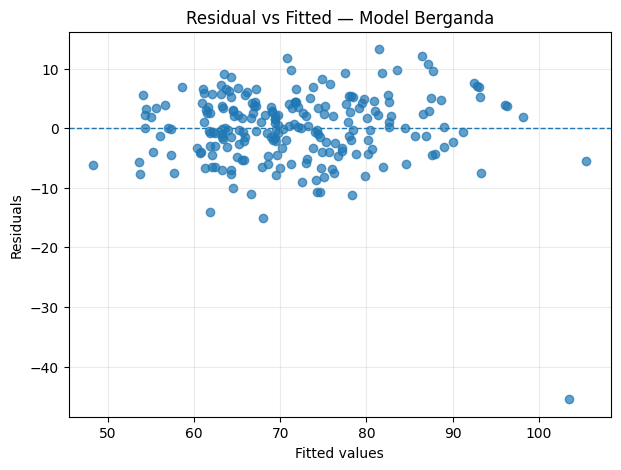

In [28]:
plt.figure(figsize=(7, 5))
plt.scatter(df_diag['fitted'], df_diag['resid'], alpha=0.70)
plt.axhline(0, linestyle='--', linewidth=1)
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residual vs Fitted — Model Berganda')
plt.grid(alpha=0.25)
plt.show()


In [29]:
# Uji Breusch-Pagan untuk heteroskedastisitas
bp_test = het_breuschpagan(model_multiple.resid, model_multiple.model.exog)
bp_labels = ['LM statistic', 'LM p-value', 'F statistic', 'F p-value']
pd.Series(bp_test, index=bp_labels)


,0
LM statistic,21.6442
LM p-value,0.0006
F statistic,4.6685
F p-value,0.0005


Interpretasi ringkas uji Breusch–Pagan:

- $H_0$: varians residual konstan atau homoskedastik.
- $H_A$: varians residual tidak konstan atau heteroskedastik.

Jika p-value kecil, terdapat indikasi heteroskedastisitas. Namun, keputusan akhir sebaiknya tetap mempertimbangkan plot residual dan konteks data.


## J.2 Diagnostik Normalitas Residual

Normalitas residual terutama penting untuk inferensi klasik, seperti uji $t$, uji $F$, dan confidence interval pada sampel kecil.

Dua alat diagnostik:

1. histogram residual;
2. QQ plot residual.


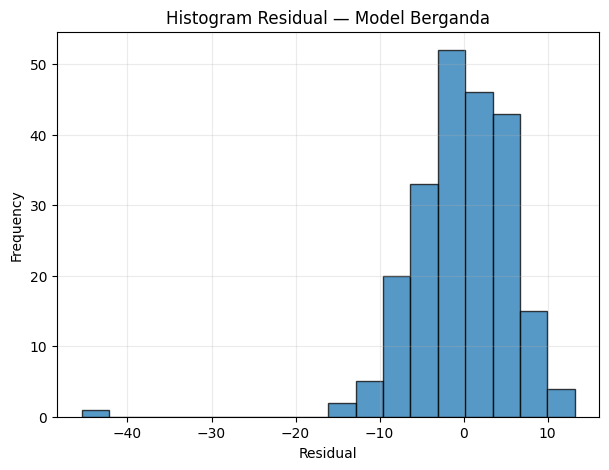

In [30]:
plt.figure(figsize=(7, 5))
plt.hist(df_diag['resid'], bins=18, edgecolor='black', alpha=0.75)
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Histogram Residual — Model Berganda')
plt.grid(alpha=0.25)
plt.show()


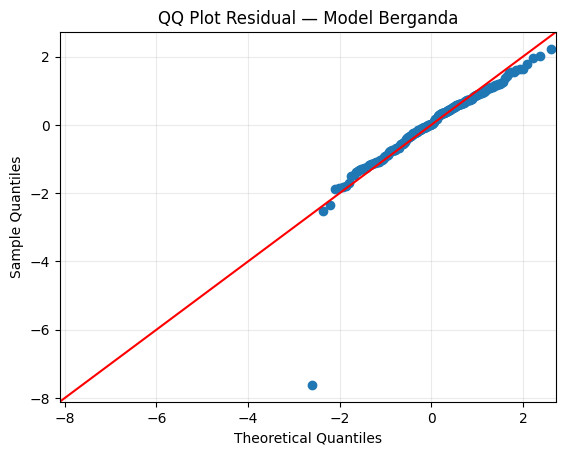

In [31]:
sm.qqplot(df_diag['resid'], line='45', fit=True)
plt.title('QQ Plot Residual — Model Berganda')
plt.grid(alpha=0.25)
plt.show()


In [32]:
# Uji Jarque-Bera dan Shapiro-Wilk
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(df_diag['resid'])
shapiro_stat, shapiro_pvalue = stats.shapiro(df_diag['resid'])

pd.DataFrame({
    'test': ['Jarque-Bera', 'Shapiro-Wilk'],
    'statistic': [jb_stat, shapiro_stat],
    'p_value': [jb_pvalue, shapiro_pvalue]
})


,test,statistic,p_value
0,Jarque-Bera,1896.7839,0.0000e+00
1,Shapiro-Wilk,0.8847,6.0072e-12


## J.3 Diagnostik Independensi Residual

Untuk data cross-sectional yang dikumpulkan secara independen, asumsi independensi biasanya bergantung pada desain pengambilan sampel.

Salah satu statistik yang sering digunakan untuk mendeteksi autokorelasi residual adalah Durbin–Watson:

$$
DW = \frac{\sum_{i=2}^{n}(e_i-e_{i-1})^2}{\sum_{i=1}^{n}e_i^2}.
$$

Nilai mendekati 2 menunjukkan tidak ada autokorelasi linear orde pertama yang kuat. Nilai jauh di bawah 2 mengindikasikan autokorelasi positif, sedangkan nilai jauh di atas 2 mengindikasikan autokorelasi negatif.


In [33]:
dw = durbin_watson(df_diag['resid'])
print(f"Durbin-Watson statistic = {dw:.4f}")


Durbin-Watson statistic = 1.7589


## J.4 Outlier, Leverage, dan Influence

Tiga konsep penting:

- **Outlier pada respons**: observasi dengan residual besar.
- **High leverage point**: observasi dengan kombinasi prediktor yang jauh dari pusat data.
- **Influential point**: observasi yang secara kuat mengubah hasil estimasi model.

Ukuran yang sering digunakan:

$$
h_{ii} = \text{diagonal ke-}i\text{ dari hat matrix } H=X(X'X)^{-1}X'.
$$

Cook's distance:

$$
D_i = \frac{e_i^2}{p\,MSE}\frac{h_{ii}}{(1-h_{ii})^2}.
$$

Aturan praktis sederhana: observasi dengan $D_i > 4/n$ perlu diperiksa lebih lanjut.


In [34]:
# Observasi dengan Cook's distance terbesar
threshold_cook = 4 / len(df_diag)
large_cook = df_diag.sort_values('cooks_d', ascending=False).head(10)

print(f"Threshold praktis Cook's D = 4/n = {threshold_cook:.4f}")
large_cook[['study_hours', 'attendance_rate', 'prior_score', 'sleep_hours', 'tutoring',
            'final_score', 'fitted', 'resid', 'leverage', 'cooks_d']]


Threshold praktis Cook's D = 4/n = 0.0181


,study_hours,attendance_rate,prior_score,sleep_hours,tutoring,final_score,fitted,resid,leverage,cooks_d
220,7.8000,96.0000,92.0000,4.0000,Ya,58.0000,103.4679,-45.4679,0.1033,1.2085
8,1.7204,65.5145,66.6952,4.2882,Tidak,47.9016,61.9211,-14.0195,0.0434,0.0424
86,2.0982,73.0875,57.4984,7.8602,Ya,52.9117,68.0424,-15.1307,0.0292,0.0322
217,1.9449,82.0919,67.7892,5.7595,Ya,82.5335,70.8225,11.7111,0.0429,0.0292
77,3.3306,82.7478,83.3572,6.4624,Tidak,94.7107,81.4730,13.2377,0.0307,0.0261
51,4.7574,71.4907,63.6327,8.2142,Tidak,67.1435,78.2805,-11.1371,0.0418,0.0257
55,2.3832,88.0082,45.0526,8.3213,Tidak,56.5033,64.2449,-7.7417,0.0697,0.0219
42,5.4086,82.6353,81.6568,5.9400,Tidak,97.1746,87.6636,9.5110,0.0411,0.0184
201,7.0293,100.0000,59.8856,8.6585,Ya,85.8693,93.3139,-7.4446,0.0625,0.0179
83,3.5493,68.5929,47.9614,6.6013,Ya,55.5590,66.5835,-11.0244,0.0294,0.0173


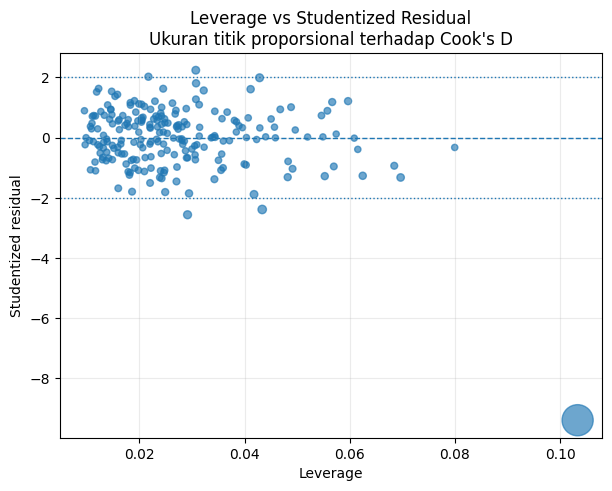

In [35]:
plt.figure(figsize=(7, 5))
plt.scatter(df_diag['leverage'], df_diag['studentized_resid'], s=400*df_diag['cooks_d']+20, alpha=0.65)
plt.axhline(0, linestyle='--', linewidth=1)
plt.axhline(2, linestyle=':', linewidth=1)
plt.axhline(-2, linestyle=':', linewidth=1)
plt.xlabel('Leverage')
plt.ylabel('Studentized residual')
plt.title("Leverage vs Studentized Residual\nUkuran titik proporsional terhadap Cook's D")
plt.grid(alpha=0.25)
plt.show()


## Checkpoint 5

Jawab secara singkat:

1. Apa tanda visual heteroskedastisitas pada residual plot?
2. Apa perbedaan outlier dan high leverage point?
3. Mengapa QQ plot digunakan pada diagnostik regresi?
4. Jika ada satu observasi dengan Cook's D besar, apakah observasi tersebut otomatis harus dihapus? Jelaskan.


In [ ]:
# Ruang jawaban Checkpoint 5
# Tulis jawaban Anda sebagai komentar di bawah ini.


# Bagian K — Prediksi dan Evaluasi pada Data Uji

Untuk tujuan prediksi, kita perlu mengevaluasi model pada data yang tidak digunakan saat pelatihan.

Kita membagi data menjadi:

- **training set**: digunakan untuk melatih model;
- **test set**: digunakan untuk mengevaluasi kemampuan generalisasi model.

Metrik yang digunakan:

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|.
$$

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2.
$$

$$
RMSE = \sqrt{MSE}.
$$

$$
R^2_{test}=1-\frac{\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}{\sum_{i=1}^{n}(y_i-\bar{y}_{test})^2}.
$$


In [37]:
train_df, test_df = train_test_split(df_clean, test_size=0.25, random_state=123)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)


Train shape: (165, 6)
Test shape : (56, 6)


In [38]:
# Melatih model pada training set
model_train = smf.ols(
    'final_score ~ study_hours + attendance_rate + prior_score + sleep_hours + C(tutoring)',
    data=train_df
).fit()

# Prediksi pada training dan test set
train_pred = model_train.predict(train_df)
test_pred = model_train.predict(test_df)

# Fungsi evaluasi prediksi
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return pd.Series({
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'R2': r2_score(y_true, y_pred)
    })

metrics = pd.DataFrame({
    'Train': regression_metrics(train_df['final_score'], train_pred),
    'Test': regression_metrics(test_df['final_score'], test_pred)
})
metrics


,Train,Test
MAE,4.3578,4.3331
MSE,39.3980,24.8727
RMSE,6.2768,4.9873
R2,0.7214,0.8024


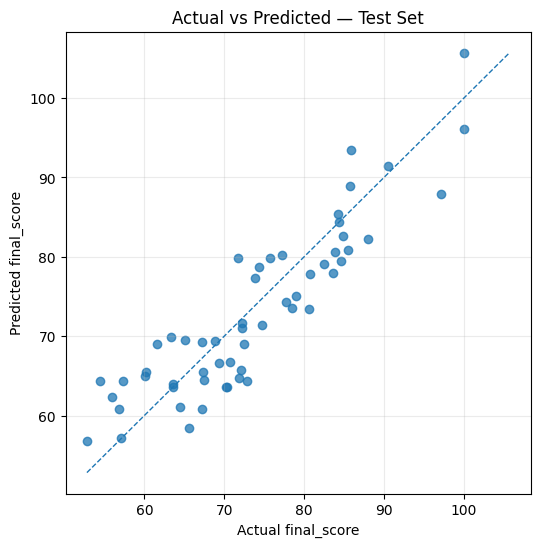

In [39]:
# Plot aktual vs prediksi pada test set
plt.figure(figsize=(6, 6))
plt.scatter(test_df['final_score'], test_pred, alpha=0.75)
min_val = min(test_df['final_score'].min(), test_pred.min())
max_val = max(test_df['final_score'].max(), test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', linewidth=1)
plt.xlabel('Actual final_score')
plt.ylabel('Predicted final_score')
plt.title('Actual vs Predicted — Test Set')
plt.grid(alpha=0.25)
plt.show()


## K.1 Interpretasi Evaluasi Prediksi

Panduan interpretasi:

- MAE menunjukkan rata-rata kesalahan absolut dalam satuan nilai akhir.
- RMSE memberi penalti lebih besar pada kesalahan besar.
- $R^2_{test}$ mengukur proporsi variasi pada data uji yang dapat dijelaskan oleh prediksi model.
- Jika performa train jauh lebih baik daripada test, ada indikasi overfitting.
- Jika performa train dan test sama-sama buruk, ada indikasi underfitting atau spesifikasi model kurang memadai.


# Bagian L — Prediksi Observasi Baru

Misalkan terdapat empat mahasiswa baru dengan karakteristik tertentu. Kita ingin memprediksi nilai akhir dan interval prediksinya.


In [40]:
new_students = pd.DataFrame({
    'study_hours': [1.5, 3.0, 5.0, 6.5],
    'attendance_rate': [60, 75, 88, 95],
    'prior_score': [58, 70, 78, 85],
    'sleep_hours': [6.0, 7.0, 7.5, 6.5],
    'tutoring': ['Tidak', 'Tidak', 'Ya', 'Ya']
})

pred_new = model_train.get_prediction(new_students).summary_frame(alpha=0.05)
prediction_table = pd.concat([new_students, pred_new], axis=1)
prediction_table


,study_hours,attendance_rate,prior_score,sleep_hours,tutoring,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,1.5,60,58,6.0,Tidak,58.3819,0.9491,56.5075,60.2563,45.6152,71.1486
1,3.0,75,70,7.0,Tidak,73.5981,0.8593,71.9011,75.2952,60.8563,86.3400
2,5.0,88,78,7.5,Ya,90.0832,1.2479,87.6187,92.5478,77.2166,102.9498
3,6.5,95,85,6.5,Ya,98.7246,1.5622,95.6393,101.8100,85.7248,111.7244


Kolom penting dari tabel prediksi:

- `mean`: prediksi rerata respons;
- `mean_ci_lower` dan `mean_ci_upper`: confidence interval untuk rerata respons;
- `obs_ci_lower` dan `obs_ci_upper`: prediction interval untuk observasi individual baru.

Prediction interval lebih lebar karena prediksi observasi individual memiliki ketidakpastian tambahan dari error acak individual.


# Bagian M — Transformasi dan Perbaikan Model

Jika diagnostik menunjukkan masalah, beberapa strategi yang dapat dipertimbangkan:

1. transformasi respons, misalnya $\log(Y)$ jika sebaran miring kanan;
2. transformasi prediktor, misalnya $\log(X)$ atau $X^2$ jika hubungan melengkung;
3. menambahkan interaksi, misalnya `study_hours * tutoring`;
4. menggunakan robust standard errors ketika heteroskedastisitas memengaruhi inferensi;
5. memeriksa data ekstrem sebelum memutuskan apakah observasi perlu dikoreksi, dipertahankan, atau dikeluarkan;
6. menggunakan model non-linear atau machine learning bila tujuan utama adalah prediksi dan pola linear tidak memadai.

Pada contoh ini, kita tambahkan komponen kuadratik untuk `sleep_hours` karena proses pembangkit data memang dibuat memiliki efek melengkung ringan.


In [41]:
model_quadratic = smf.ols(
    'final_score ~ study_hours + attendance_rate + prior_score + sleep_hours + I(sleep_hours**2) + C(tutoring)',
    data=df_clean
).fit()

comparison2 = pd.DataFrame({
    'Model': ['Multiple linear', 'With sleep_hours quadratic'],
    'R2': [model_multiple.rsquared, model_quadratic.rsquared],
    'Adjusted_R2': [model_multiple.rsquared_adj, model_quadratic.rsquared_adj],
    'AIC': [model_multiple.aic, model_quadratic.aic],
    'BIC': [model_multiple.bic, model_quadratic.bic]
})
comparison2


,Model,R2,Adjusted_R2,AIC,BIC
0,Multiple linear,0.7430,0.7370,1428.9299,1449.3188
1,With sleep_hours quadratic,0.7816,0.7755,1394.9976,1418.7847


In [42]:
print(model_quadratic.summary())


                            OLS Regression Results                            
Dep. Variable:            final_score   R-squared:                       0.782
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                     127.6
Date:                Sat, 09 May 2026   Prob (F-statistic):           7.29e-68
Time:                        12:26:32   Log-Likelihood:                -690.50
No. Observations:                 221   AIC:                             1395.
Df Residuals:                     214   BIC:                             1419.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept             -82.0420    

## M.1 Robust Standard Errors

Jika model rerata dianggap cukup masuk akal tetapi ada indikasi heteroskedastisitas, salah satu pendekatan inferensial adalah menggunakan **heteroskedasticity-consistent standard errors**.

Model koefisien tidak berubah, tetapi standard error, statistik uji, dan p-value dapat berubah.


In [43]:
# Robust standard errors tipe HC3
model_multiple_robust = model_multiple.get_robustcov_results(cov_type='HC3')
print(model_multiple_robust.summary())


                            OLS Regression Results                            
Dep. Variable:            final_score   R-squared:                       0.743
Model:                            OLS   Adj. R-squared:                  0.737
Method:                 Least Squares   F-statistic:                     87.72
Date:                Sat, 09 May 2026   Prob (F-statistic):           5.83e-50
Time:                        12:26:35   Log-Likelihood:                -708.46
No. Observations:                 221   AIC:                             1429.
Df Residuals:                     215   BIC:                             1449.
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             7.8699      4.28

# Bagian N — Kesalahan Interpretasi yang Sering Terjadi

Beberapa kesalahan umum dalam regresi linear:

1. Menganggap korelasi atau koefisien regresi sebagai bukti kausalitas tanpa desain penelitian yang mendukung.
2. Menginterpretasikan intercept padahal $X=0$ tidak masuk akal atau berada jauh di luar rentang data.
3. Menggunakan model untuk ekstrapolasi jauh di luar rentang data.
4. Mengandalkan $R^2$ saja tanpa memeriksa residual dan konteks model.
5. Mengabaikan outlier, high leverage, atau influential point.
6. Menginterpretasikan koefisien berganda tanpa memperhatikan multikolinearitas.
7. Menyamakan confidence interval dengan prediction interval.
8. Menilai model prediksi hanya dari training error.


# Bagian O — Ringkasan Rumus Utama

| Konsep | Rumus | Keterangan |
|---|---|---|
| Model sederhana | $Y_i=\beta_0+\beta_1X_i+\varepsilon_i$ | satu prediktor |
| Model berganda | $Y_i=\beta_0+\sum_{j=1}^{p}\beta_jX_{ij}+\varepsilon_i$ | beberapa prediktor |
| Fitted value | $\hat{y}_i=\hat\beta_0+\sum_j\hat\beta_jX_{ij}$ | nilai prediksi model |
| Residual | $e_i=y_i-\hat{y}_i$ | selisih aktual dan prediksi |
| SSE | $\sum e_i^2$ | error tidak terjelaskan |
| SST | $\sum(y_i-\bar{y})^2$ | variasi total respons |
| $R^2$ | $1-SSE/SST$ | proporsi variasi yang dijelaskan model |
| Adjusted $R^2$ | $1-(1-R^2)\frac{n-1}{n-p-1}$ | penyesuaian jumlah prediktor |
| MAE | $n^{-1}\sum|y_i-\hat{y}_i|$ | rata-rata error absolut |
| RMSE | $\sqrt{n^{-1}\sum(y_i-\hat{y}_i)^2}$ | akar rata-rata error kuadrat |
| VIF | $1/(1-R_j^2)$ | diagnostik multikolinearitas |
| Durbin–Watson | $\frac{\sum_{i=2}^{n}(e_i-e_{i-1})^2}{\sum e_i^2}$ | indikasi autokorelasi residual |


# Bagian P — Template Interpretasi Hasil Regresi

Gunakan template berikut untuk menulis interpretasi hasil regresi.

## P.1 Interpretasi Model Sederhana

“Model regresi linear sederhana menunjukkan bahwa `...` berhubungan positif/negatif dengan `...`. Koefisien slope sebesar `...` berarti setiap kenaikan satu unit `...` berkaitan dengan perubahan rata-rata `...` sebesar `...` satuan. Nilai $R^2$ sebesar `...` menunjukkan bahwa sekitar `...%` variasi respons dapat dijelaskan oleh prediktor dalam model. Berdasarkan residual plot, asumsi linearitas dan kesamaan varians tampak ...”

## P.2 Interpretasi Model Berganda

“Setelah mengendalikan prediktor lain, koefisien `...` sebesar `...` menunjukkan bahwa setiap kenaikan satu unit `...` berkaitan dengan perubahan rata-rata respons sebesar `...` satuan. Koefisien ini perlu ditafsirkan secara *ceteris paribus*. Nilai adjusted $R^2$ sebesar `...` menunjukkan kualitas kecocokan model setelah memperhitungkan jumlah prediktor. Diagnostik residual menunjukkan ...”

## P.3 Interpretasi Prediksi

“Pada data uji, model menghasilkan MAE sebesar `...` dan RMSE sebesar `...`. Artinya, kesalahan prediksi rata-rata berada sekitar `...` satuan nilai akhir. Selisih performa train dan test menunjukkan bahwa model ... mengalami/tidak mengalami indikasi overfitting yang kuat.”


# Bagian Q — Latihan Terstruktur

Latihan berikut dikerjakan langsung di notebook.


## Latihan 1 — Eksplorasi Hubungan

Gunakan dataset `df_clean`.

1. Buat scatterplot `final_score` terhadap `prior_score`.
2. Tambahkan garis regresi sederhana.
3. Jelaskan arah, bentuk, dan kekuatan hubungan secara singkat.


In [ ]:
# Latihan 1
# Tulis kode Anda di bawah ini.


## Latihan 2 — Regresi Linear Sederhana

Buat model:

$$
\texttt{final\_score} \sim \texttt{prior\_score}.
$$

Tampilkan:

1. ringkasan model;
2. koefisien slope;
3. confidence interval 95% untuk slope;
4. interpretasi slope dalam konteks pendidikan.


In [ ]:
# Latihan 2
# Tulis kode Anda di bawah ini.


## Latihan 3 — Regresi Linear Berganda

Buat model regresi berganda dengan prediktor:

- `study_hours`,
- `attendance_rate`,
- `prior_score`,
- `sleep_hours`,
- `tutoring`.

Kemudian interpretasikan minimal dua koefisien numerik dan satu koefisien kategorik.


In [ ]:
# Latihan 3
# Tulis kode Anda di bawah ini.


## Latihan 4 — Diagnostik Asumsi

Untuk model pada Latihan 3:

1. buat residual vs fitted plot;
2. buat histogram residual;
3. buat QQ plot residual;
4. hitung Breusch–Pagan test;
5. tuliskan kesimpulan diagnostik model.


In [ ]:
# Latihan 4
# Tulis kode Anda di bawah ini.


## Latihan 5 — Evaluasi Prediksi

Bagi data menjadi training set dan test set. Latih model pada training set dan hitung MAE, RMSE, dan $R^2$ pada test set.

Tuliskan apakah model cukup baik untuk prediksi berdasarkan metrik tersebut.


In [ ]:
# Latihan 5
# Tulis kode Anda di bawah ini.


# Bagian R — Tugas Week 11

Gunakan **1 dataset publik** atau dataset sintetis yang Anda rancang sendiri, relevan dengan topik pendidikan, kesehatan, ekonomi, bisnis, lingkungan, atau sosial. Lakukan analisis regresi linear secara lengkap dengan tahapan berikut.

## Soal

### 1. Jelaskan dataset yang digunakan

Jelaskan:

- nama dataset;
- sumber dataset atau alasan pembuatan dataset sintetis;
- unit analisis;
- variabel respons;
- variabel prediktor;
- jenis variabel: numerik atau kategorik.

### 2. Muat dataset ke Python menggunakan `pandas`

Tampilkan:

- `shape`;
- `head()`;
- `info()`;
- `describe()`;
- jumlah missing values;
- jumlah data duplikat.

### 3. Lakukan eksplorasi data

Minimal tampilkan:

- distribusi variabel respons;
- scatterplot respons terhadap minimal dua prediktor numerik;
- korelasi antarvariabel numerik;
- ringkasan respons berdasarkan satu variabel kategorik jika tersedia.

### 4. Bangun model regresi linear sederhana

Pilih satu prediktor utama dan buat model:

$$
Y_i=\beta_0+\beta_1X_i+\varepsilon_i.
$$

Tampilkan:

- ringkasan model;
- persamaan regresi estimasi;
- interpretasi intercept dan slope;
- nilai $R^2$;
- residual plot.

### 5. Bangun model regresi linear berganda

Gunakan minimal dua prediktor. Tampilkan:

- ringkasan model;
- interpretasi minimal tiga koefisien;
- $R^2$ dan adjusted $R^2$;
- confidence interval koefisien;
- VIF untuk memeriksa multikolinearitas.

### 6. Periksa asumsi regresi linear

Periksa:

- linearitas;
- homoskedastisitas;
- normalitas residual;
- independensi residual jika relevan;
- outlier, leverage, dan influence.

Gunakan visualisasi dan/atau uji statistik yang sesuai.

### 7. Lakukan prediksi dan evaluasi model

Bagi data menjadi train dan test set. Hitung minimal:

- MAE;
- RMSE;
- $R^2$ test.

Buat plot aktual vs prediksi dan tuliskan interpretasi.

### 8. Tulis kesimpulan akhir

Kesimpulan harus memuat:

- prediktor yang paling penting secara statistik atau substantif;
- apakah model cukup baik untuk interpretasi;
- apakah model cukup baik untuk prediksi;
- keterbatasan analisis;
- rekomendasi perbaikan model.


# Bagian S — Rubrik Penilaian Tugas Week 11

| Komponen | Bobot | Kriteria Penilaian |
|---|---:|---|
| Deskripsi dataset | 10% | Dataset dijelaskan lengkap: sumber, unit analisis, respons, prediktor, jenis variabel |
| Pemeriksaan awal data | 10% | Menampilkan `shape`, `head`, `info`, `describe`, missing values, dan duplikasi |
| Eksplorasi data | 15% | Visualisasi dan ringkasan hubungan awal dibuat serta diinterpretasikan dengan benar |
| Regresi linear sederhana | 15% | Model, persamaan, koefisien, $R^2$, dan residual plot disajikan serta diinterpretasikan |
| Regresi linear berganda | 20% | Model berganda, interpretasi koefisien, adjusted $R^2$, confidence interval, dan VIF lengkap |
| Diagnostik asumsi | 15% | Linearitas, homoskedastisitas, normalitas residual, outlier/leverage/influence diperiksa secara tepat |
| Prediksi dan evaluasi | 10% | Train-test split, MAE, RMSE, $R^2$ test, dan plot aktual vs prediksi disajikan |
| Kesimpulan dan komunikasi | 5% | Kesimpulan jelas, kontekstual, dan membedakan interpretasi, inferensi, serta prediksi |
| **Total** | **100%** |  |


# Bagian T — Ringkasan Akhir

Poin utama Week 11:

1. Regresi linear memodelkan rerata respons sebagai fungsi linear dari prediktor.
2. OLS memilih koefisien yang meminimumkan jumlah kuadrat residual.
3. Residual adalah alat utama untuk memeriksa kecukupan model.
4. Koefisien regresi sederhana dan berganda memiliki interpretasi berbeda.
5. Interpretasi koefisien berganda bersifat *ceteris paribus*.
6. $R^2$ mengukur variasi yang dijelaskan model, tetapi tidak cukup untuk menyatakan model valid.
7. Confidence interval dan prediction interval menjawab pertanyaan berbeda.
8. Model untuk prediksi harus dievaluasi pada data uji, bukan hanya data latih.
9. Diagnostik asumsi penting untuk inferensi dan interpretasi yang dapat dipertanggungjawabkan.
10. Regresi tidak membuktikan kausalitas tanpa desain penelitian atau argumen kausal yang kuat.


# Referensi Pembelajaran

1. Montgomery, D. C., Peck, E. A., & Vining, G. G. (2021). *Introduction to Linear Regression Analysis* (6th ed.). Wiley.
2. De Veaux, R. D., Velleman, P. F., & Bock, D. E. (2022). *Intro Stats* (6th ed.). Pearson.
3. Pengantar Data Sains — Course Plan. Meeting 12: Statistical Modeling & Prediction.
4. Datasans. *Dasar-Dasar Python untuk Data Science*.
5. Datasans. *Cheatsheet Statistika untuk Data Science*.

Notebook ini disusun untuk pembelajaran mahasiswa S1. Fokus utama adalah pemahaman konsep, praktik Python, interpretasi model, dan kehati-hatian dalam penggunaan regresi linear untuk inferensi dan prediksi.
